In [4]:
import pandas as pd
import os
import numpy as np
from sklearn import preprocessing

In [ ]:
data_training = pd.read_csv("/content/TRAINING_NORMAL.csv")
data_testing = pd.read_csv("/content/TESTING_NORMAL.csv")

In [6]:
#Shuffling the data for better results
#data=data.reindex(np.random.permutation(data.index))

In [7]:
#y = data['Label']
#data = data.drop(['Label','TimeStamp','TimeStamp_Readable','seconds_of_timestamp','CQ_AF3','CQ_T7','CQ_Pz','CQ_T8','CQ_AF4'], axis = 1)

In [8]:
#data.head()

In [9]:
#dropping the un-named Column
data_training = data_training.drop(data_training.columns[0], axis=1)
data_testing = data_testing.drop(data_testing.columns[0], axis=1)

In [10]:
y_train = data_training['label']
x_train = data_training.drop(columns='label', axis=1)
y_test = data_testing['label']
x_test = data_testing.drop(columns='label', axis=1)

In [11]:
#RandomForest Algorithm.
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=400,max_depth = 8)#parameter tuning, 200 decision trees of depth 8
#fitting the model
model.fit(x_train,y_train)
predict=model.predict(x_test)
print("Training Accuracy :", model.score(x_train, y_train))
print("Testing Accuracy :", model.score(x_test, y_test))
cr = classification_report(y_test, predict)
print(cr)

Training Accuracy : 0.9375
Testing Accuracy : 0.5078125
              precision    recall  f1-score   support

           1       0.39      0.17      0.24       215
           2       0.29      0.20      0.23       239
           3       0.57      0.76      0.65       570

    accuracy                           0.51      1024
   macro avg       0.42      0.38      0.38      1024
weighted avg       0.47      0.51      0.47      1024



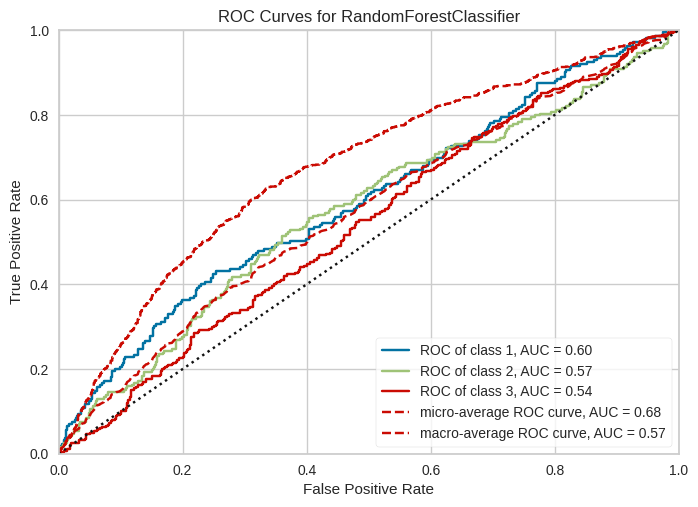

<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [12]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(model)

visualizer.fit(x_train, y_train)
visualizer.score(x_test, y_test)
visualizer.show()

In [13]:
def plot_confusion_matrix(y_test, result, classes, normalize=False, title=None, cmap=plt.cm.Blues):
 """
431 This function prints and plots the confusion matrix.
432 Normalization can be applied by setting ‘normalize=True‘.
433 """
 if not title:
  if normalize:
    title = 'Normalized confusion matrix'
  else:
    title = 'Confusion matrix, without normalization'

 # Compute confusion matrix
 cm = confusion_matrix(y_test, result)
# Only use the labels that appear in the data
# classes = classes[unique_labels(y_test, result)]
 if normalize:
  cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  print("Normalized confusion matrix")
 else:
  print('Confusion matrix, without normalization')
 print(cm)
 fig, ax = plt.subplots()
 im = ax.imshow(cm, interpolation='nearest', cmap = cmap)
 ax.figure.colorbar(im, ax=ax)
 # We want to show all ticks...
 ax.set(xticks=np.arange(cm.shape[1]),
  yticks = np.arange(cm.shape[0]),
  # ... and label them with the respective list entries
  xticklabels = classes, yticklabels = classes,
  title = title,
  ylabel ='True label',
  xlabel ='Predicted label')
 # Rotate the tick labels and set their alignment.
 plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
 rotation_mode = "anchor")
 # Loop over data dimensions and create text annotations.
 fmt = '.2f' if normalize else 'd'
 thresh = cm.max() / 2.
 for i in range(cm.shape[0]):
     for j in range(cm.shape[1]):
         ax.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", color="white" if cm[i, j] > thresh else "black")
 fig.tight_layout()
 return ax

Confusion matrix, without normalization
[[ 37  25 153]
 [ 15  47 177]
 [ 42  92 436]]
Normalized confusion matrix
[[0.17 0.12 0.71]
 [0.06 0.2  0.74]
 [0.07 0.16 0.76]]


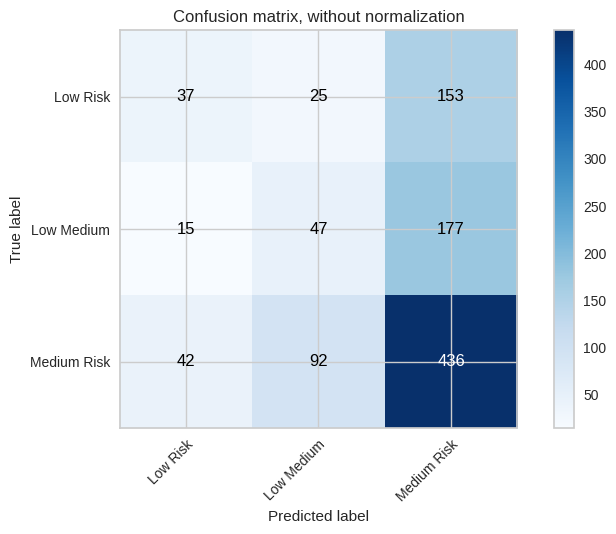

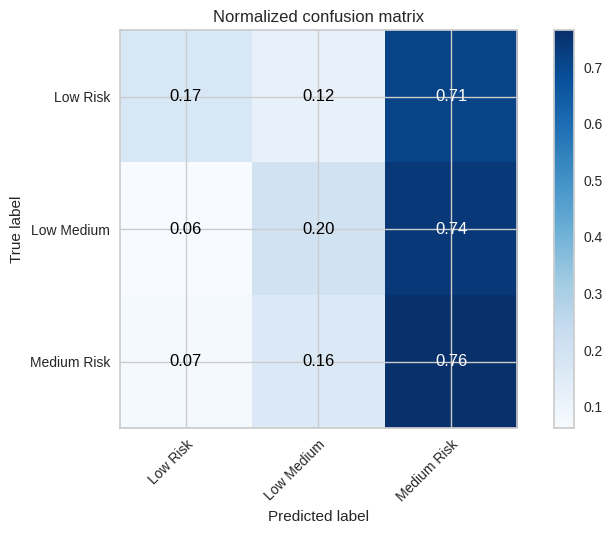

In [15]:
np.set_printoptions(precision=2)
class_names = ['Low Risk', 'Low Medium', 'Medium Risk']
# Plot non-normalized confusion matrix
plot_confusion_matrix(y_test, predict, classes=class_names, title='Confusion matrix, without normalization')
# Plot normalized confusion matrix
plot_confusion_matrix(y_test, predict, classes=class_names, normalize=True, title='Normalized confusion matrix')
plt.show()

In [16]:
from sklearn import metrics
accu = metrics.accuracy_score(y_test, predict)
recall = metrics.recall_score(y_test, predict,average="macro")
precision = metrics.precision_score(y_test, predict,average="macro")
F1 = metrics.f1_score(y_test, predict,average="macro")
print(accu,recall,precision,F1)

0.5078125 0.3778860078742801 0.4164643292174825 0.3751424772576956


In [17]:
#from sklearn.externals import joblib
import joblib
joblib.dump(model,"rf_joblib_model")
rf = joblib.load("rf_joblib_model")

In [18]:
!pip install eli5
!pip install shap
!pip install pdpbox

In [19]:
# importing ML Explanability Libraries
#for purmutation importance
import eli5
from eli5.sklearn import PermutationImportance
#for SHAP values
import shap
from pdpbox import pdp, info_plots #for partial plots

In [20]:
perm = PermutationImportance(model, random_state = 0).fit(x_test, y_test)
eli5.show_weights(perm, feature_names = x_test.columns.tolist())

Weight,Feature
0.0033 ± 0.0032,Pz_theta
0.0025 ± 0.0047,Pz_gamma
0.0023 ± 0.0078,AF3_high_beta
0.0020 ± 0.0048,T8_alpha
0.0020 ± 0.0033,T8_low_beta
0.0014 ± 0.0060,T7_low_beta
0.0012 ± 0.0053,Pz_high_beta
0.0004 ± 0.0032,AF3_gamma
0.0002 ± 0.0034,AF3_alpha
0.0002 ± 0.0026,AF3_low_beta


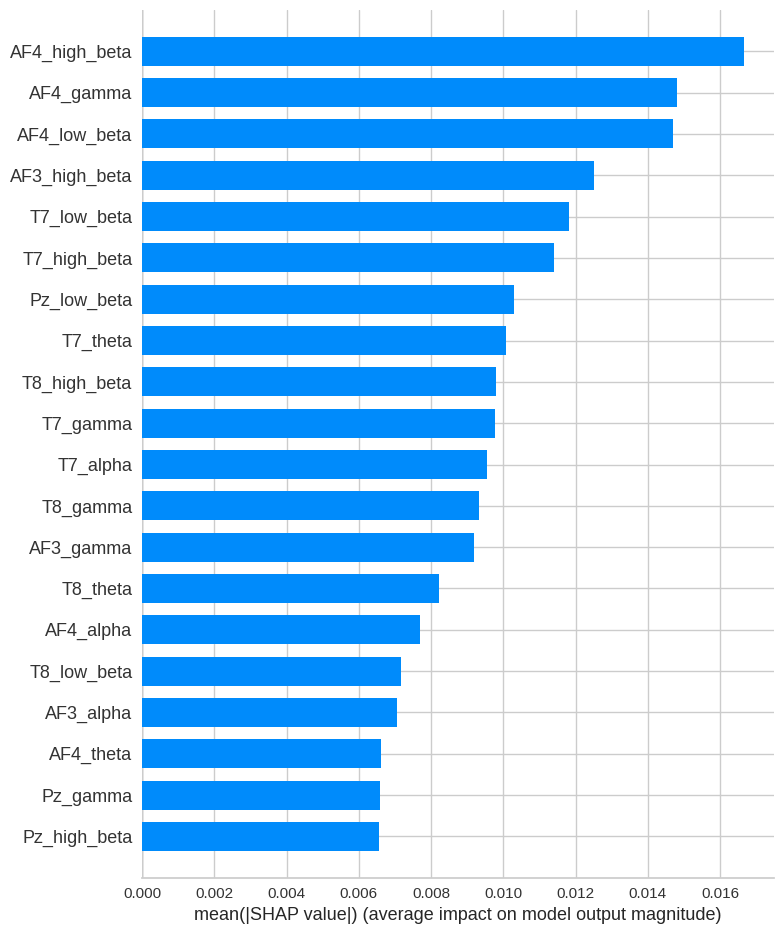

In [22]:
# let’s see the shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values[:, :, 1], x_test, plot_type="bar")

In [25]:
def record_analysis(model, record):
 explainer = shap.TreeExplainer(model)
 shap_values = explainer.shap_values(record)
 shap.initjs()
 return shap.force_plot(explainer.expected_value[1], shap_values[:, 1], record)

In [26]:
#1st Record
record = x_test.iloc[1,:].astype(float)
record_analysis(model, record)

In [27]:
#2nd Record
record = x_test.iloc[2,:].astype(float)
record_analysis(model, record)

In [28]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=526d3871a8db676cfbe002f26ba885edd2372c69dbead4e1115f59fa38652b77
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


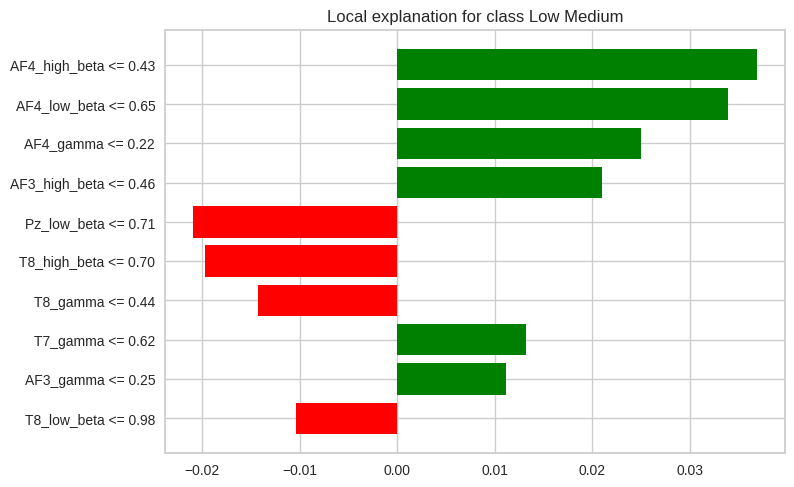

In [29]:
from lime.lime_tabular import LimeTabularExplainer

feature_names = x_test.columns.tolist()
explainer = LimeTabularExplainer(x_test.iloc[:,:].values, feature_names=feature_names, class_names=class_names)
exp = explainer.explain_instance(x_test.iloc[2,:].values, model.predict_proba)
fig = exp.as_pyplot_figure()

In [30]:
exp.show_in_notebook(show_table=True, show_all=False)

In [31]:
from sklearn import tree

cls_t = tree.DecisionTreeClassifier()
cls_t.fit(x_test, predict)

DecisionTreeClassifier()

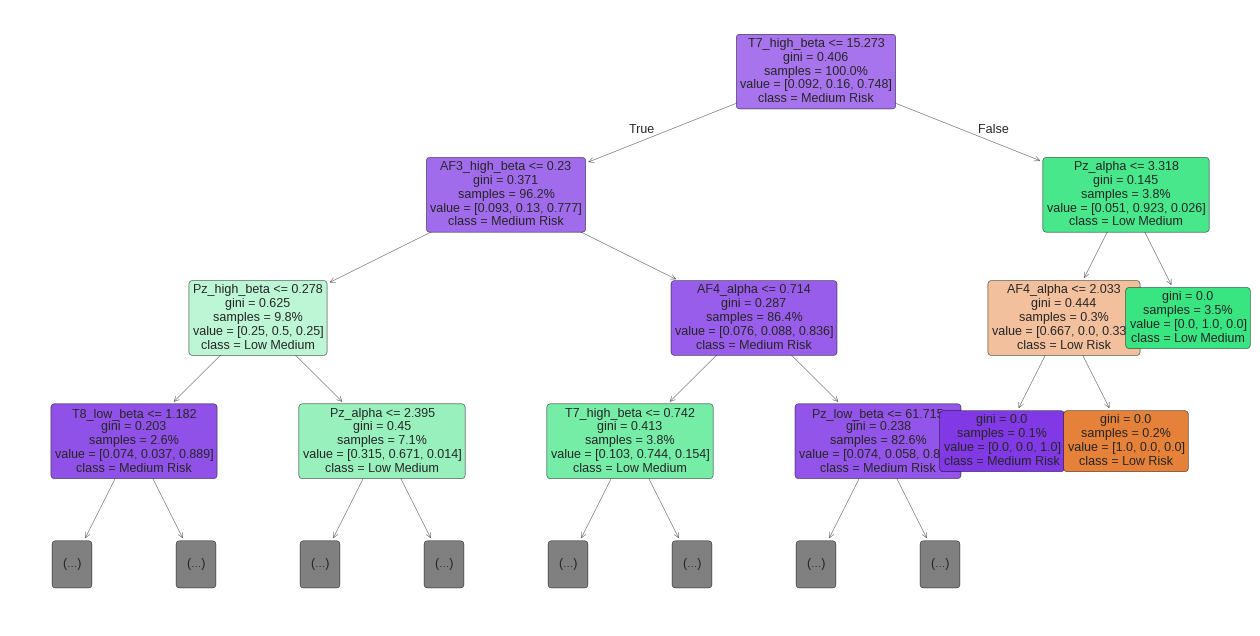

In [32]:
fig = plt.figure(figsize=(16, 8))
vis = tree.plot_tree(cls_t, feature_names = feature_names, class_names = class_names, max_depth=3, fontsize=9, proportion=True, filled=True, rounded=True)